**Libraries**

In [34]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

**Data preprocessing**

In [7]:
data = pd.read_csv("titanic.csv")
data.isna().sum()
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
x = data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = data['Survived']

In [9]:
x['Sex'] = x['Sex'].map({"female": 0, "male": 1})
x['Age'] = x['Age'].fillna(x['Age'].median())

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

**DecisionTreeClassifier**

In [14]:
dtclf = DecisionTreeClassifier(criterion="gini", max_depth=3, min_samples_leaf=5, random_state=42)
dtclf.fit(x_train, y_train)
y_pred_dtclf = dtclf.predict(x_test)

In [19]:
print(classification_report(y_test, y_pred_dtclf))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [21]:
print(accuracy_score(y_test, y_pred_dtclf))

0.7988826815642458


In [23]:
print(confusion_matrix(y_test, y_pred_dtclf))

[[92 13]
 [23 51]]


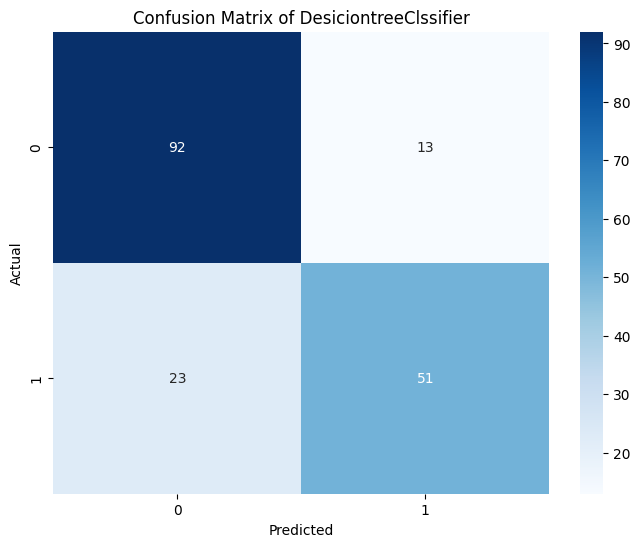

In [37]:
cm = confusion_matrix(y_test, y_pred_dtclf)
plt.figure(figsize=(8, 6))
sn.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of DesiciontreeClssifier")
plt.show()

**RandomforestClassifier**

In [29]:
rfclf = RandomForestClassifier(n_estimators=100, random_state=42)
rfclf.fit(x_train, y_train)
y_pred_rfclf = rfclf.predict(x_test)

In [30]:
print(classification_report(y_test, y_pred_rfclf))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [31]:
print(accuracy_score(y_test, y_pred_rfclf))

0.7988826815642458


In [33]:
print(confusion_matrix(y_test, y_pred_rfclf))

[[89 16]
 [20 54]]


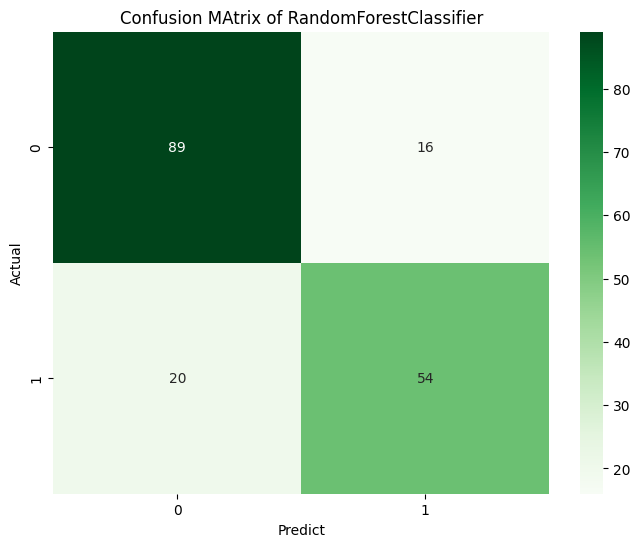

In [40]:
cm = confusion_matrix(y_test, y_pred_rfclf)
plt.figure(figsize=(8, 6))
sn.heatmap(cm, annot=True, cmap="Greens")
plt.title("Confusion MAtrix of RandomForestClassifier")
plt.xlabel("Predict")
plt.ylabel("Actual")
plt.show()